In [ ]:
# Load from local folders instead of GitHub
# Data already in Germany/ and Netherlands/ folders
print("✓ Using local data folders (Germany/ and Netherlands/)")

Cloning into 'WetLinks'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 84 (delta 4), reused 6 (delta 1), pack-reused 70 (from 1)
Receiving objects: 100% (84/84), 100.75 MiB | 10.15 MiB/s, done.
Resolving deltas: 100% (23/23), done.
Updating files: 100% (58/58), done.


In [ ]:
import os

os.listdir("WetLinks/Preprocessed_Data")

['iperf_cleaned_seconds_Enschede.csv',
 'iperf_cleaned_seconds_Osnabrück.csv',
 'iperf_cleaned_means_Osnabrück.csv',
 'iperf_cleaned_means_Enschede.csv',
 'analysis_data_Enschede.csv',
 'analysis_data_Osnabrück.csv']

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [3]:
# Load from local folders (Germany and Netherlands)
# Adjust paths since notebook is in notebooks/ folder
data_path = "../data/raw"

# seconds datasets
df_sec_ens = pd.read_csv(f"{data_path}/Netherlands/iperf_cleaned_seconds_Enschede.csv")
df_sec_osn = pd.read_csv(f"{data_path}/Germany/iperf_cleaned_seconds_Osnabrück.csv")

# means datasets
df_mean_ens = pd.read_csv(f"{data_path}/Netherlands/iperf_cleaned_means_Enschede.csv")
df_mean_osn = pd.read_csv(f"{data_path}/Germany/iperf_cleaned_means_Osnabrück.csv")

# analysis datasets
df_ens = pd.read_csv(f"{data_path}/Netherlands/analysis_data_Enschede.csv")
df_osn = pd.read_csv(f"{data_path}/Germany/analysis_data_Osnabrück.csv")

print("✓ All local CSV files loaded successfully!")

✓ All local CSV files loaded successfully!


In [4]:
df_ens["region"] = "Enschede"
df_osn["region"] = "Osnabrück"

In [5]:
df = pd.concat([df_ens, df_osn], ignore_index=True)

df.head()

,Unnamed: 0,site_name,timestamp_start,timestamp_end,server,ip_protocol,transport_protocol,download,download_std,upload,...,dewpt,windchill,winddir,windspeed,windgust,rain,solarradiation,uv,barom,region
0,0,utwente,2023-10-12 15:43:52,2023-10-12 15:44:07,131.173.23.81,v4,UDP,1.710447e+08,3.586019e+07,NaN,...,14.633333,14.933333,326.333333,0.867257,2.433387,1.998133,78.533333,0.0,1007.790000,Enschede
1,1,utwente,2023-10-12 15:50:46,2023-10-12 15:51:01,131.173.23.81,v4,UDP,3.075971e+08,3.943962e+07,2.554027e+07,...,14.800000,15.100000,347.000000,1.265123,3.334917,0.609600,45.726667,0.0,1007.756667,Enschede
2,2,utwente,2023-10-12 15:54:17,2023-10-12 15:54:32,131.173.23.81,v4,UDP,2.734449e+08,3.663568e+07,1.790420e+07,...,14.766667,15.200000,113.000000,0.900042,1.867138,0.203200,26.993333,0.0,1007.990000,Enschede
3,3,utwente,2023-10-12 15:57:26,2023-10-12 15:57:41,131.173.23.81,v4,UDP,3.084543e+08,3.434000e+07,NaN,...,14.733333,15.233333,142.666667,0.767419,1.865647,0.000000,20.600000,0.0,1008.090000,Enschede
4,4,utwente,2023-10-12 16:00:56,2023-10-12 16:01:11,131.173.23.81,v4,UDP,2.629533e+08,2.577178e+07,1.529387e+07,...,14.800000,15.300000,174.000000,1.133992,1.899919,0.000000,16.993333,0.0,1008.400000,Enschede


In [ ]:
df.shape

(116956, 32)

In [ ]:
df.columns

Index(['Unnamed: 0', 'site_name', 'timestamp_start', 'timestamp_end', 'server',
       'ip_protocol', 'transport_protocol', 'download', 'download_std',
       'upload', 'upload_std', 'measurement_steps', 'ping_target',
       'ping_ip_protocol', 'ping_packet_loss', 'ping_packets_send', 'ping_avg',
       'ping_worst', 'ping_best', 'ping_stddev', 'temp', 'humidity', 'dewpt',
       'windchill', 'winddir', 'windspeed', 'windgust', 'rain',
       'solarradiation', 'uv', 'barom', 'region'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116956 entries, 0 to 116955
Data columns (total 32 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Unnamed: 0          116956 non-null  int64  
 1   site_name           116956 non-null  object 
 2   timestamp_start     116956 non-null  object 
 3   timestamp_end       116956 non-null  object 
 4   server              116956 non-null  object 
 5   ip_protocol         116956 non-null  object 
 6   transport_protocol  116956 non-null  object 
 7   download            111004 non-null  float64
 8   download_std        111004 non-null  float64
 9   upload              103966 non-null  float64
 10  upload_std          103966 non-null  float64
 11  measurement_steps   116956 non-null  int64  
 12  ping_target         116954 non-null  object 
 13  ping_ip_protocol    116954 non-null  object 
 14  ping_packet_loss    116954 non-null  float64
 15  ping_packets_send   116954 non-nul

In [ ]:
df.describe()

,Unnamed: 0,download,download_std,upload,upload_std,measurement_steps,ping_packet_loss,ping_packets_send,ping_avg,ping_worst,...,humidity,dewpt,windchill,winddir,windspeed,windgust,rain,solarradiation,uv,barom
count,116956.000000,1.110040e+05,1.110040e+05,1.039660e+05,1.039660e+05,116956.0,116954.000000,116954.0,116954.000000,116954.000000,...,103851.000000,103851.000000,103851.000000,103851.000000,103851.000000,103851.000000,103851.000000,103851.000000,103851.000000,103851.000000
mean,30113.993014,2.183807e+08,3.703465e+07,1.724396e+07,3.456919e+06,15.0,0.323508,250.0,62.347427,115.568344,...,76.762532,0.037885,1.441495,177.590596,-3.052040,-1.329214,0.143001,26.448417,-10.628692,1002.870838
std,18314.106599,6.725730e+07,1.905271e+07,7.498970e+06,2.492679e+06,0.0,1.614171,0.0,7.501472,58.130447,...,323.419836,178.855765,178.932335,334.997252,143.310690,143.378885,0.683733,331.339030,320.446672,12.456982
min,0.000000,0.000000e+00,0.000000e+00,1.953400e+05,1.080620e+05,15.0,0.000000,250.0,37.284000,51.865000,...,-9999.000000,-5572.780000,-5572.780000,-9999.000000,-4469.944444,-4469.944444,0.000000,-9999.000000,-9999.000000,963.495333
25%,14619.000000,1.749834e+08,2.384486e+07,1.227900e+07,1.760146e+06,15.0,0.000000,250.0,57.305250,93.955250,...,82.000000,3.000000,3.866667,132.333333,0.900041,1.800081,0.000000,0.000000,0.000000,994.142000
50%,29238.500000,2.222321e+08,3.293042e+07,1.577137e+07,2.756538e+06,15.0,0.000000,250.0,61.867000,108.026500,...,90.666667,6.333333,7.333333,195.666667,1.500565,2.932590,0.000000,0.000000,0.000000,1003.016667
75%,43858.000000,2.637354e+08,4.558582e+07,2.030493e+07,4.343260e+06,15.0,0.400000,250.0,66.538750,125.852000,...,96.000000,9.233333,10.966667,249.666667,2.433384,4.799722,0.000000,40.041667,0.000000,1012.426667
max,68596.000000,4.328610e+08,1.723181e+08,7.645260e+07,3.071486e+07,15.0,87.200000,250.0,244.949000,10358.700000,...,99.000000,18.866667,27.000000,359.000000,10.666380,18.400176,35.204400,709.260000,6.000000,1032.276667


In [6]:
df = df.drop(columns=["Unnamed: 0"])

In [7]:
df["timestamp_start"] = pd.to_datetime(df["timestamp_start"])
df["timestamp_end"] = pd.to_datetime(df["timestamp_end"])

In [8]:
df["hour"] = df["timestamp_start"].dt.hour
df["day"] = df["timestamp_start"].dt.day
df["month"] = df["timestamp_start"].dt.month
df["day_of_week"] = df["timestamp_start"].dt.dayofweek

In [ ]:
df.isnull().sum()

,0
site_name,0
timestamp_start,0
timestamp_end,0
server,0
ip_protocol,0
transport_protocol,0
download,5952
download_std,5952
upload,12990
upload_std,12990


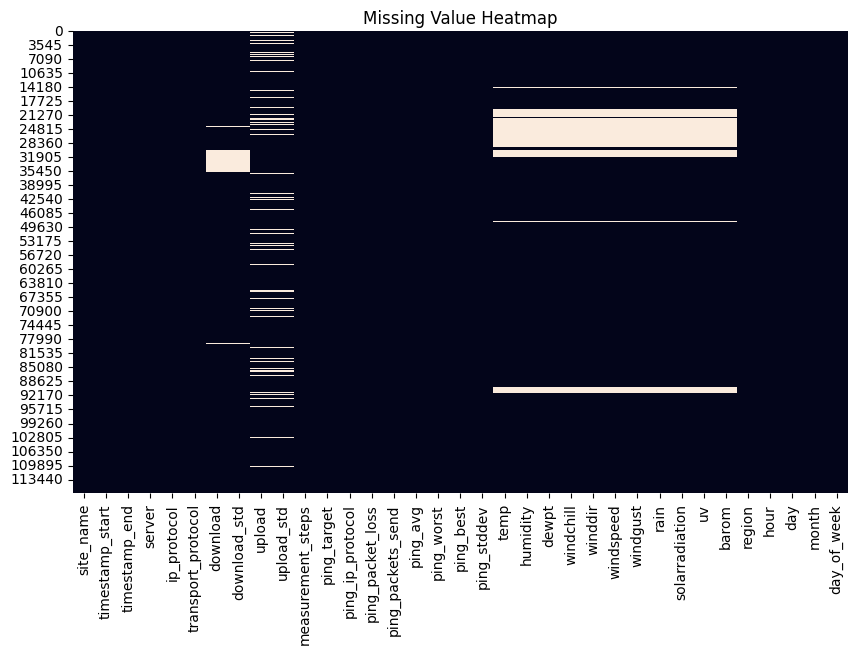

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [9]:
df = df.fillna(df.median(numeric_only=True))

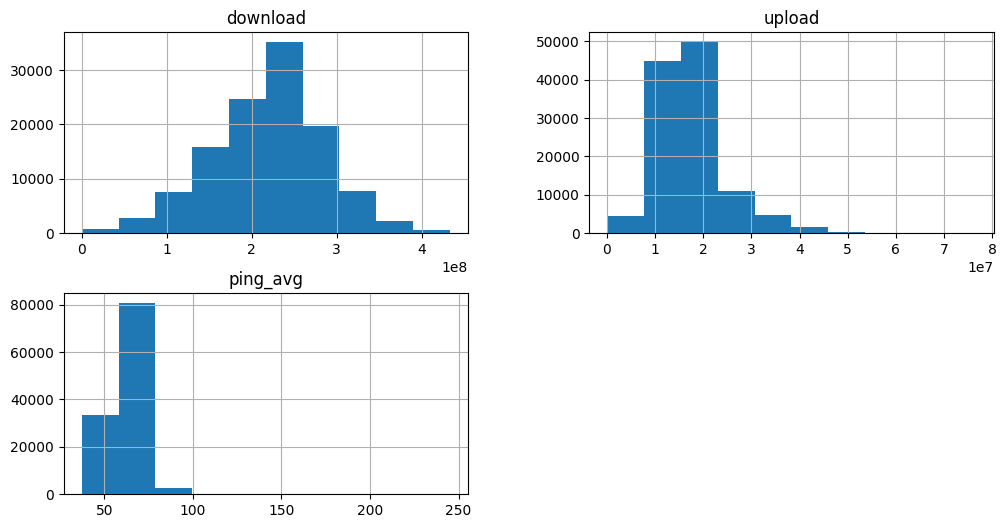

In [ ]:
df[["download","upload","ping_avg"]].hist(figsize=(12,6))
plt.show()

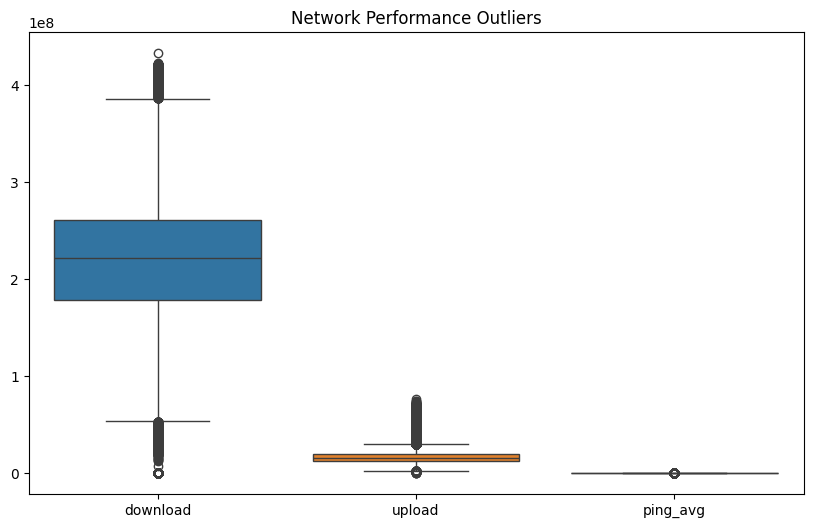

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[["download","upload","ping_avg"]])
plt.title("Network Performance Outliers")
plt.show()

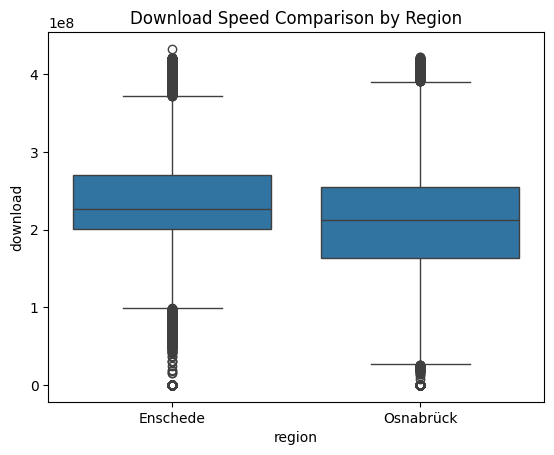

In [ ]:
sns.boxplot(x="region", y="download", data=df)
plt.title("Download Speed Comparison by Region")
plt.show()

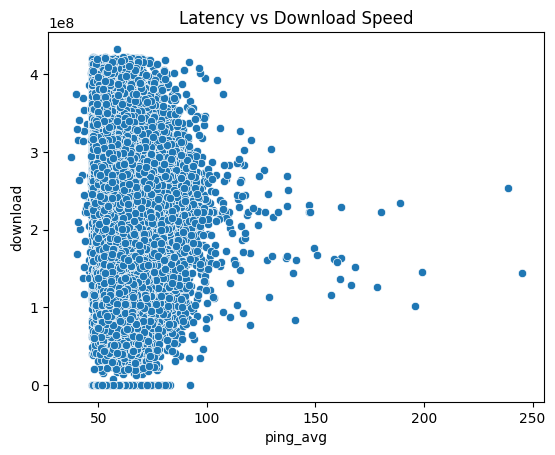

In [ ]:
sns.scatterplot(x="ping_avg", y="download", data=df)
plt.title("Latency vs Download Speed")
plt.show()

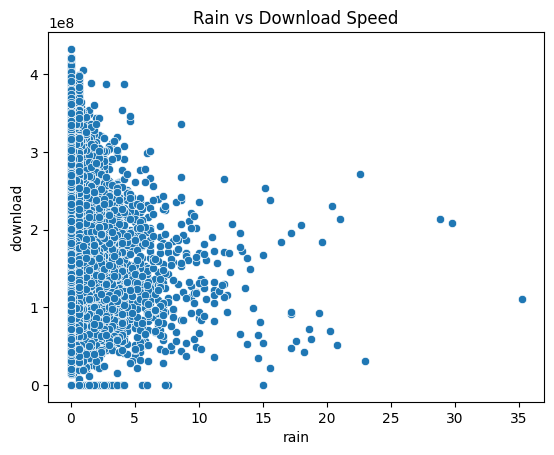

In [ ]:
sns.scatterplot(x="rain", y="download", data=df)
plt.title("Rain vs Download Speed")
plt.show()

In [10]:
df["network_stability"] = df["ping_stddev"]

In [11]:
df["total_bandwidth"] = df["download"] + df["upload"]

In [12]:
df["efficiency"] = df["download"] / (df["ping_avg"] + 1)

In [13]:
df["weather_severity"] = (
    df["rain"] +
    df["windspeed"] +
    df["humidity"]
)

In [14]:
df["packet_loss_flag"] = (df["ping_packet_loss"] > 0).astype(int)

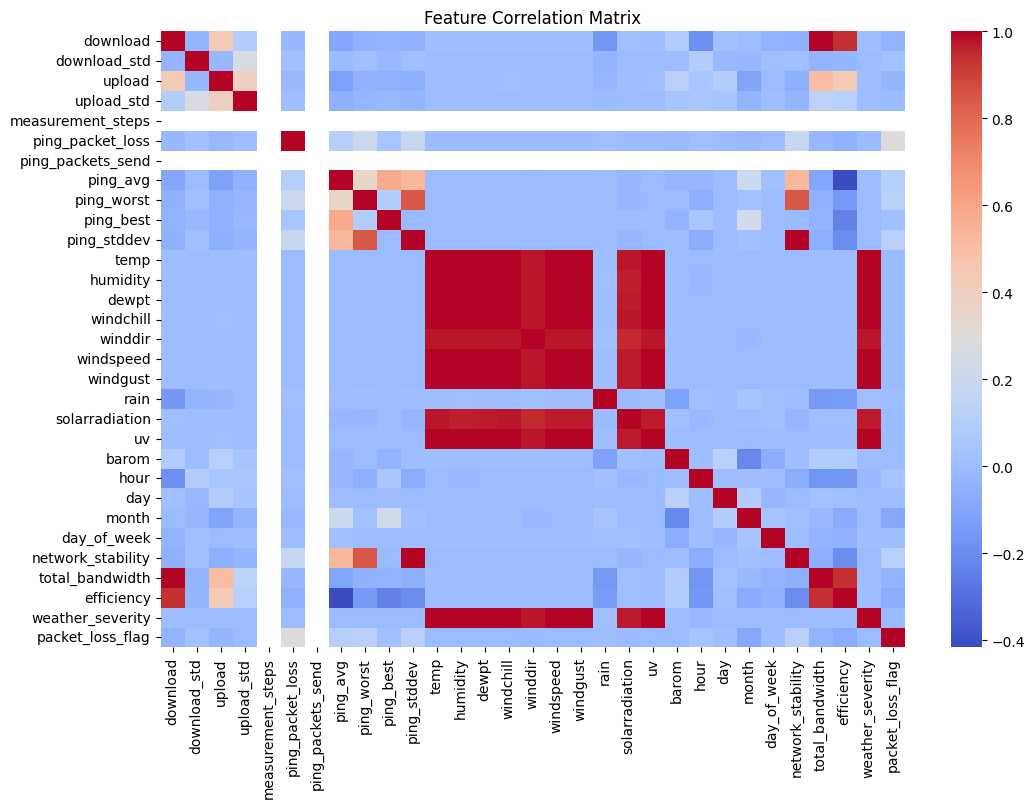

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

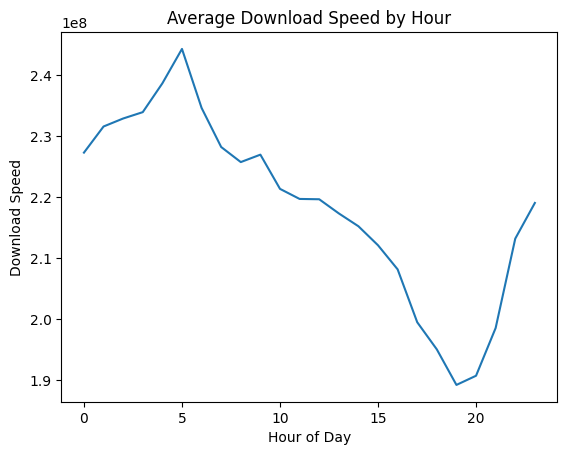

In [ ]:
df.groupby("hour")["download"].mean().plot()
plt.title("Average Download Speed by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Download Speed")
plt.show()

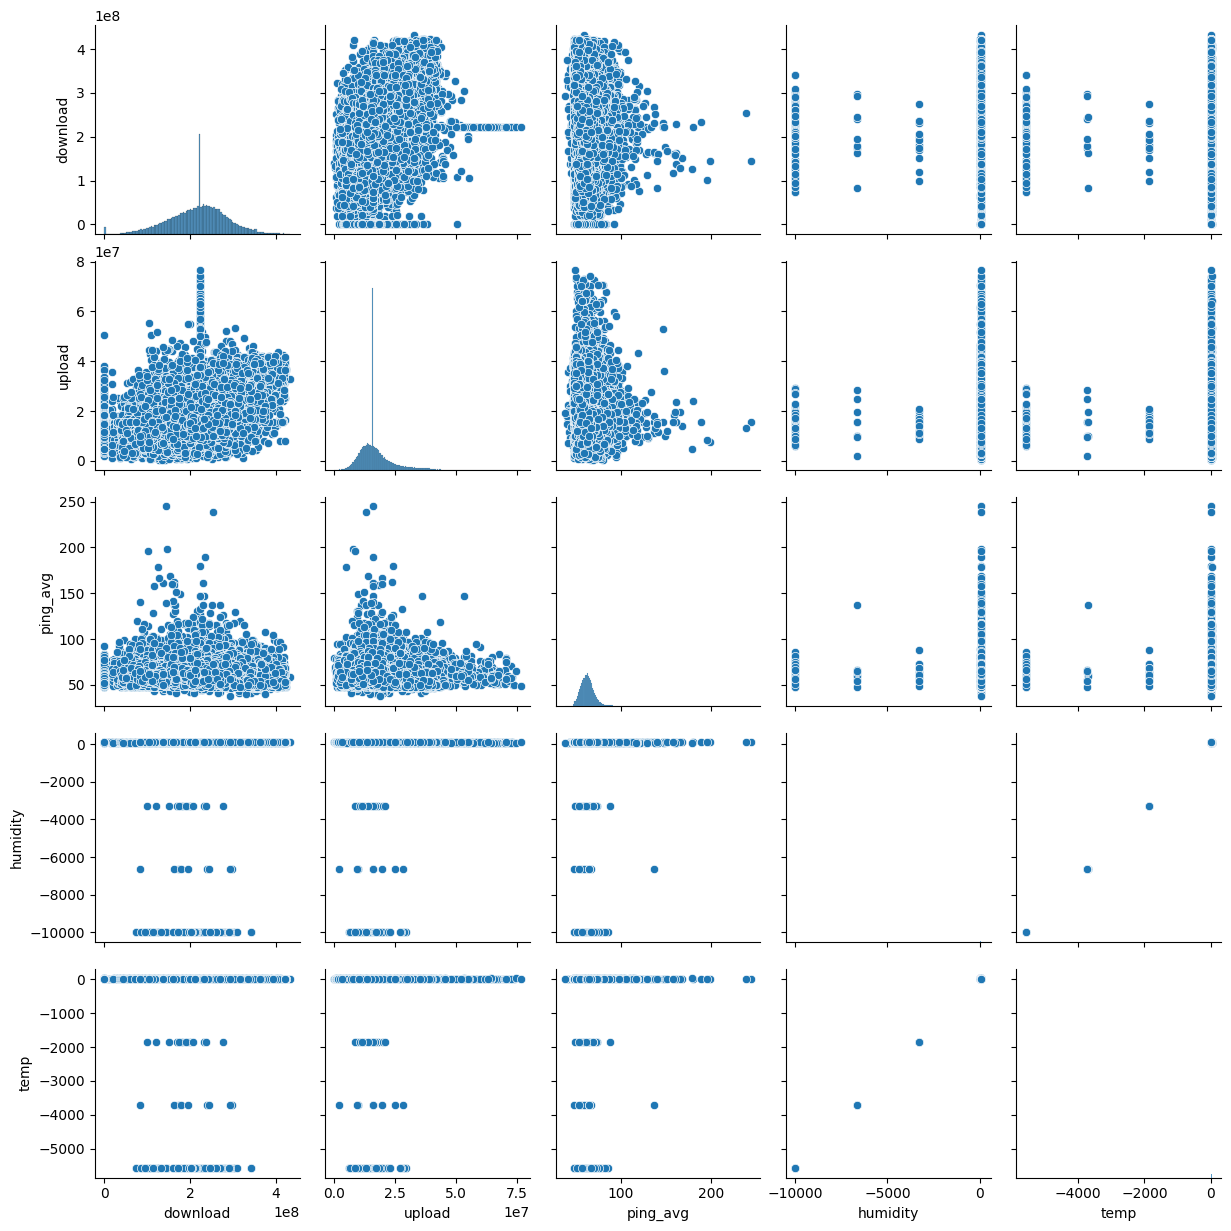

In [ ]:
sns.pairplot(df[["download","upload","ping_avg","humidity","temp"]])
plt.show()

In [15]:
scaler = StandardScaler()

num_cols = df.select_dtypes(include=["float64","int64"]).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

In [16]:
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

df = df.drop(columns=to_drop)

In [ ]:
df.head()

,site_name,timestamp_start,timestamp_end,server,ip_protocol,transport_protocol,download,download_std,upload,upload_std,...,ping_stddev,temp,rain,barom,region,hour,day,month,day_of_week,packet_loss_flag
0,utwente,2023-10-12 15:43:52,2023-10-12 15:44:07,131.173.23.81,v4,UDP,-0.725362,-0.051960,-0.184753,-0.263760,...,0.705215,0.072084,2.897142,0.417674,Enschede,15,12,10,3,-0.668976
1,utwente,2023-10-12 15:50:46,2023-10-12 15:51:01,131.173.23.81,v4,UDP,1.358494,0.140654,1.193991,1.435282,...,-0.090034,0.073073,0.747253,0.414835,Enschede,15,12,10,3,-0.668976
2,utwente,2023-10-12 15:54:17,2023-10-12 15:54:32,131.173.23.81,v4,UDP,0.837316,-0.010229,0.116267,0.320586,...,0.009295,0.073666,0.118017,0.434713,Enschede,15,12,10,3,-0.668976
3,utwente,2023-10-12 15:57:26,2023-10-12 15:57:41,131.173.23.81,v4,UDP,1.371575,-0.133764,-0.184753,-0.263760,...,1.084947,0.073863,-0.196601,0.443232,Enschede,15,12,10,3,-0.668976
4,utwente,2023-10-12 16:00:56,2023-10-12 16:01:11,131.173.23.81,v4,UDP,0.677208,-0.594832,-0.252145,-0.109045,...,2.294015,0.074259,-0.196601,0.469641,Enschede,16,12,10,3,-0.668976


In [ ]:
df.shape

(116956, 28)

In [17]:
df.to_csv("../data/final_engineered_dataset.csv", index=False)
print(f"✓ Engineered dataset saved: {df.shape[0]} rows × {df.shape[1]} columns")

✓ Engineered dataset saved: 116956 rows × 28 columns
